In [2]:
%matplotlib ipympl

import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import netCDF4 as nc
import glob

In [3]:
### FUNCTION LIBRARY ###
def read_csv_file(file_path):
    values = []
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            values.extend(row)
    return values

## Load Datasets

In [4]:
# Load GRUAN data
years = ['2005','2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021'] # Years of interest

# Get all GRUAN radiosonde files
files = []
for year in years:
    files.extend(glob.glob('/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/'+'/**/'+year+'/*.nc', recursive=True))
files.sort()
num_files = len(files)

num_files = 1 # For testing purposes
for i in range(num_files):
    path2file = files[i]
    nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
    GRUAN_RHw = nc_GRUAN.variables['rh'][:] # [unitless, not %]
    GRUAN_RHi = nc_GRUAN.variables['rh_i'][:] # [unitless, not %]
    
    altitude = nc_GRUAN.variables['alt'][:]  # Assuming 'alt' is the variable for altitude

    nc_GRUAN.close()


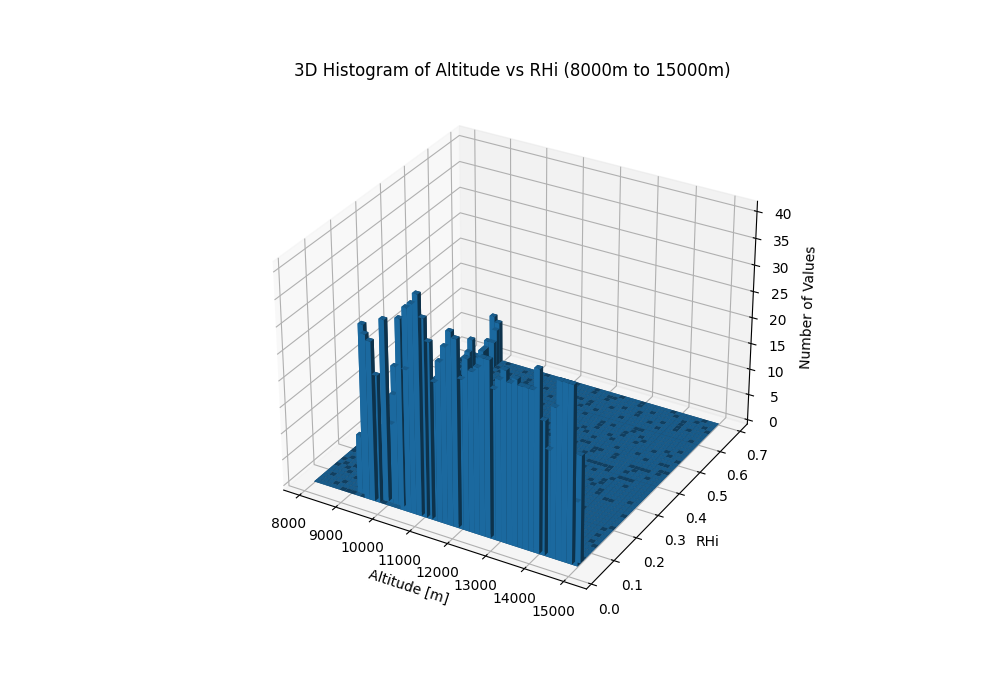

In [5]:
# Enable interactive mode
%matplotlib ipympl

from mpl_toolkits.mplot3d import Axes3D 

# Filter the data for altitudes between 8000m and 15000m
altitude_mask = (altitude >= 8000) & (altitude <= 15000)
filtered_altitude = altitude[altitude_mask]
filtered_RHi = GRUAN_RHi[altitude_mask]

# Define the number of bins for altitude and RHi
num_bins_altitude = 50
num_bins_RHi = 50

# Create the histogram
hist, edges = np.histogramdd((filtered_altitude, filtered_RHi), bins=(num_bins_altitude, num_bins_RHi))

# Get the bin centers
altitude_centers = (edges[0][:-1] + edges[0][1:]) / 2
RHi_centers = (edges[1][:-1] + edges[1][1:]) / 2

# Create a meshgrid for plotting
altitude_mesh, RHi_mesh = np.meshgrid(altitude_centers, RHi_centers, indexing="ij")

# Plot the 3D histogram
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use bar3d to create the 3D histogram
xpos, ypos = np.meshgrid(altitude_centers, RHi_centers, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)
dx = (edges[0][1] - edges[0][0]) * np.ones_like(zpos)
dy = (edges[1][1] - edges[1][0]) * np.ones_like(zpos)
dz = hist.ravel()

chart = ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')
ax.set_xlabel('Altitude [m]')
ax.set_ylabel('RHi')
ax.set_zlabel('Number of Values')
ax.set_title('3D Histogram of Altitude vs RHi (8000m to 15000m)')
plt.show()

In [6]:
# Load ERA5 data 

# Provide the path to your CSV file
era5_data_path = '/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_processed.csv'

# Call the function to read the CSV file
ERA5_data = pd.read_csv(era5_data_path)
ERA5_data = ERA5_data.dropna()

In [6]:
# Assign values to arrays
ERA5_MLD = ERA5_data['MLD'].values
ERA5_RH = ERA5_data['cruiseRH'].values

In [ ]:
ERA5_data

In [ ]:
print(len(GRUAN_MLD))
print(len(GRUAN_RH))
print(len(ERA5_MLD))
print(len(ERA5_RH))

# Plot GRUAN Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log')
ax.set_title("GRUAN Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 Meteorological Data

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', alpha=0.4)
ax.set_title("ERA5 Supersaturation and Moist Layer Depth, 2005-2021")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
plt.ylim(0, 5000)
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 vs GRUAN Meteorological Data

In [ ]:
# Clean out 0 values

In [ ]:
plt.rcParams['figure.dpi'] = 300

fig, ax1  = plt.subplots()
ax2 = ax1.twinx()
hb1 = ax1.hexbin(x = ERA5_RH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', 
                 label='ERA5', alpha=0.4)
hb2 = ax2.hexbin(x = GRUAN_RH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log', 
                 label='GRUAN', alpha=0.4)
ax1.set_title("Supersaturation and Moist Layer Depth")
ax1.set_xlabel("Cruise RH wrt ice [%]")
ax1.set_ylabel("Moist Layer Depth [m]")
ax1.set_ylim(0, 1000)
ax2.set_ylim(0, 1000)
ax1.legend()
ax2.legend()

# cb1 = fig.colorbar(hb1, ax=ax1, pad = 0.99, location='right')
cb2 = fig.colorbar(hb2, ax=ax2, pad = 0.2, label='Counts', location='left')
plt.show()

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_MLD, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_MLD, ax = ax1, kde=False, label = 'ERA5', color='blue')
ax.set_xlabel("Moist Layer Depth [m]")
plt.title("Moist Layer Depth Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
ax1.set_xlim(0,4000)
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_RH, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_RH, ax = ax1, kde=True, label = 'ERA5', color='blue')
ax.set_xlabel("Relative Humidity [%]")
plt.title("Relative Humidity Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

In [ ]:
# Plot GRUAN and ERA5 for the same stations and times

# Calculate KL-Divergence between the two distributions

In [ ]:
def norm_kl_divergence(a, b): # a is treated as the "true" distribution
    KL_div = np.abs(np.sum(a * np.log(a/b)))/len(a)
    return KL_div
def delete_negative_values(arr):
    return arr[arr >= 0]

GRUAN_MLD_no_neg = delete_negative_values(GRUAN_MLD)
ERA5_MLD_no_neg = delete_negative_values(ERA5_MLD)
GRUAN_RH_no_neg = delete_negative_values(GRUAN_RH)
ERA5_RH_no_neg = delete_negative_values(GRUAN_RH)

num_samples = 1000000
rand_GRUAN_MLD = np.random.choice(GRUAN_MLD_no_neg, size = num_samples)
rand_ERA5_MLD = np.random.choice(ERA5_MLD_no_neg, size = num_samples)
rand_GRUAN_RH = np.random.choice(GRUAN_RH_no_neg, size = num_samples)
rand_ERA5_RH = np.random.choice(ERA5_RH_no_neg, size = num_samples)

MLD_norm_kl_div = norm_kl_divergence(rand_GRUAN_MLD, rand_ERA5_MLD)
RH_norm_kl_div = norm_kl_divergence(rand_GRUAN_RH, rand_ERA5_RH)

print("Bits required per MLD datapoint", MLD_norm_kl_div)
print("Bits required per RH datapoint", RH_norm_kl_div)

## XX Plot of GRUAN and ERA5 Data at Matching Sites

In [ ]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name
color_options = ['green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
plt.figure(figsize=(10, 6))
plt.rcParams['figure.dpi'] = 300
j = -1

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    if not np.isnan(GRUAN_RH[i]) and not np.isnan(ERA5_RH[i]):
        if site_name in legend_keys:
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], color=colors[site_name], s = 16)
        else:
            print("New site!", site_name)
            if site_name not in colors:
                j = j+1
                colors[site_name] = color_options[j]  # generate a random color for new site_name
            
            plt.scatter(GRUAN_RH[i], ERA5_RH[i], label=site_name, color=colors[site_name], s = 16)
            legend_keys.add(site_name)

plt.ylim(90,150)
plt.xlim(90,150)
corr_xy = np.linspace(0, len(ERA5_data))
plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN Cruise RH wrt ice [%]')
plt.ylabel('ERA5 Cruise RH wrt ice [%]')
plt.title('ERA5 vs GRUAN Cruise RH')
plt.legend(loc='upper left')  # move the legend to the bottom right
plt.show()


In [ ]:


site_data_dict = {}  # dictionary to store data for each site_name
for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    
    # Save data for each site_name
    if np.isnan(GRUAN_RH[i]) or np.isnan(ERA5_RH[i]):
        continue
    else:
        site_data = {'GRUAN_RH': GRUAN_RH[i], 'ERA5_RH': ERA5_RH[i]}
    
    if site_name not in site_data_dict:
        site_data_dict[site_name] = []
    site_data_dict[site_name].append(site_data)

# Plot each site_name separately
for site_name, site_data in site_data_dict.items():
    site_data = pd.DataFrame(site_data)
    print(site_data['GRUAN_RH'].size)
    plt.scatter(site_data['GRUAN_RH'], site_data['ERA5_RH'], color = colors[site_name], label=site_name, s = 16)
    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')

    plt.ylim(90,150)
    plt.xlim(90,150)
    corr_xy = np.linspace(0, len(ERA5_data))
    plt.plot(corr_xy, corr_xy, color='lightgray')  # add x=y line using default xlim and ylim

    plt.xlabel('GRUAN Cruise RH wrt ice [%]')
    plt.ylabel('ERA5 Cruise RH wrt ice [%]')
    plt.title('ERA5 vs GRUAN Cruise RH')
    plt.legend(loc='lower right')  # move the legend to the bottom right
    plt.show()

print(site_data_dict.keys())

In [ ]:
import os

parent_directory = '/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/'
site_directories = ['BEL', 'BOU', 'CAB', 'GRA', 'LIN', 'PAY', 'POT', 'SGP', 'TAT']  # Replace with the actual site directories

for site_directory in site_directories:
    site_path = os.path.join(parent_directory, site_directory)
    file_count = sum(len(files) for _, _, files in os.walk(site_path))
    print(f"Site Directory: {site_directory}, File Count: {file_count}")

In [ ]:
legend_keys = set()
colors = {}  # dictionary to store colors for each site_name

for i in range(len(ERA5_data)):
    site_name = ERA5_data['GRUAN_site_name'][i]
    if site_name in legend_keys:
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], color=colors[site_name])
    else:
        if site_name not in colors:
            colors[site_name] = np.random.rand(3,)  # generate a random color for new site_name
        plt.scatter(GRUAN_MLD[i], ERA5_MLD[i], label=site_name, color=colors[site_name])
        legend_keys.add(site_name)

plt.plot(plt.xlim(), plt.ylim(), color='lightgray')  # add x=y line using default xlim and ylim

plt.xlabel('GRUAN MLD [m]')
plt.ylabel('ERA5 MLD [m]')
plt.title('ERA5 vs GRUAN MLD')
plt.legend(loc='lower right')  # move the legend to the bottom right
plt.show()